# Superoperator analysis from grid data

Analyse `data/grid/superoperator_N4_grid_<number>.npz`. Select the alpha and sigma values below; the corresponding plots only include those values.

In [2]:
%matplotlib inline

from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import numpy as np
import pandas as pd         
PLOT_DIR = Path('docu/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

## Load grid

Set the grid-file number here.

In [17]:
# npz-number
# grid_nr = 6
grid_nr = 15

N = 4
path = Path(f"data/grid/superoperator_N{N}_grid_{grid_nr}.npz")

# Optional Nelder-Mead h/J sweep archive. Both direct sweep archives and
# older converted grid-analysis archives are supported.
nm_path = None
# nm_path = Path('data/nelder_mead/nelder_mead_N4_h_sweep_2.npz')
# nm_path = Path('data/nelder_mead/nelder_mead_N4_h_sweep_2_runs/nelder_mead_N4_h_sweep_2_grid_analysis.npz')

data = np.load(path)
nm_data = np.load(nm_path) if nm_path is not None else None

# Use the selected Nelder-Mead archive's run number in plot filenames.
nm_run_nr = None
if nm_path is not None:
    nm_run_match = re.fullmatch(r'nelder_mead_N\d+_h_sweep_(\d+)(?:_grid_analysis)?', nm_path.stem)
    if nm_run_match is None:
        raise ValueError(f'Cannot determine Nelder-Mead run number from {nm_path.name}')
    nm_run_nr = int(nm_run_match.group(1))

print(f"Loaded: {path}")
print(f"Grid points: {len(data['h'])}")
if nm_data is not None:
    print(f"Loaded optimized values: {nm_path}")
    print(f"Optimized points: {len(nm_data['h_over_J'])}")


Loaded: data/grid/superoperator_N4_grid_15.npz
Grid points: 60


## Alpha selection

The cell prints every alpha value in the file. Edit `alphas_to_plot` to choose the curves shown in the alpha plots; use `None` for all available values.

In [18]:
# Reconstructed run configuration for the saved beta sweeps.  The archives
# contain h and beta directly; the remaining shared values are the sweep
# script settings used to create this series.
beta_plot_parameters = {
    'N': 4,
    'J': 1.0,
    'h': 1.2,
    'T': 25.0,
    'sigma': 2.0,
    'omega_max': 20.0,
    'tau': 0.1,
    'eps_fit': 0.05,
    'beta_min': 0.1,
    'beta_max': 100.0,
    'beta_points': 20,
    'beta_spacing': 'geometric',
    'op_set': 'XZ',
    'normalize_Jh': False,
    'dense_spectrum': False,
    'save_channel': False,
}

# (npz-number, alpha)
alpha_values = np.unique(data['alpha'])
print('Available alpha values:', alpha_values.tolist())

alphas_to_plot = [0.25, 0.5, 0.75, 1.0, 1.5]  # set to None to include all alpha values
alphas_to_plot = None

selected_alphas = alpha_values if alphas_to_plot is None else np.asarray(alphas_to_plot)
missing_alphas = np.setdiff1d(selected_alphas, alpha_values)
if len(missing_alphas):
    raise ValueError(f'alpha values not present in grid: {missing_alphas.tolist()}')
print('Alpha values included in plots:', selected_alphas.tolist())

Available alpha values: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
Alpha values included in plots: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]


## Sigma selection

The cell prints every sigma value in the file. Edit `sigmas_to_plot` to choose the curves shown in the sigma plots; use `None` for all available values.

In [19]:
# (npz-number, sigma)
sigma_values = np.unique(data['sigma'])
print('Available sigma values:', sigma_values.tolist())

sigmas_to_plot = [0.5, 0.875, 1.25, 1.625, 2.0]  # set to None to include all sigma values
sigmas_to_plot = None

selected_sigmas = sigma_values if sigmas_to_plot is None else np.asarray(sigmas_to_plot)
missing_sigmas = np.setdiff1d(selected_sigmas, sigma_values)
if len(missing_sigmas):
    raise ValueError(f'sigma values not present in grid: {missing_sigmas.tolist()}')
print('Sigma values included in plots:', selected_sigmas.tolist())

Available sigma values: [2.0]
Sigma values included in plots: [2.0]


In [20]:
# Grid archives do not record T; set this to the value used for the selected run.
grid_T = 25.0

grid_h_over_J = data['h_over_J'] if 'h_over_J' in data.files else data['h'] / data['J']
grid_data = pd.DataFrame({
    'h': data['h'],
    'h_over_J': grid_h_over_J,
    'alpha': data['alpha'],
    'sigma': data['sigma'],
    'omega_max': data['omega_max'],
    'Delta_sep': data['Delta_sep'],
    'trace_distance': data['trace_distance'],
    'normality_residual': data['normality_residual'],
    'num_iterations': data['num_iterations'],
})

grid_data['effective_iteration_time'] = (
    grid_data['num_iterations'] * 2 * grid_T * grid_data['alpha']**2
)

nm_grid_data = None
if nm_data is not None:
    nm_h_over_J = nm_data['h_over_J']
    nm_alpha = nm_data['alpha_opt'] if 'alpha_opt' in nm_data.files else nm_data['alpha']
    nm_omega_max = nm_data['omega_max_opt'] if 'omega_max_opt' in nm_data.files else nm_data['omega_max']
    nm_sigma = nm_data['sigma_opt'] if 'sigma_opt' in nm_data.files else nm_data['sigma']
    nm_T = nm_data['T_opt'] if 'T_opt' in nm_data.files else nm_data['T']
    nm_tau = nm_data['tau_opt'] if 'tau_opt' in nm_data.files else nm_data['tau']
    nm_num_iterations = nm_data['num_iterations']
    nm_grid_data = pd.DataFrame({
        'h_over_J': nm_h_over_J,
        'alpha': nm_alpha,
        'sigma': nm_sigma,
        'omega_max': nm_omega_max,
        'T': nm_T,
        'tau': nm_tau,
        'num_iterations': nm_num_iterations,
        'Delta_sep': nm_data['Delta_sep'],
        'Delta_gap': nm_data['Delta_gap'],
    })
    if 'normality_residual' in nm_data.files:
        nm_grid_data['normality_residual'] = nm_data['normality_residual']
    if 'effective_iteration_time' in nm_data.files:
        nm_grid_data['effective_iteration_time'] = nm_data['effective_iteration_time']
    else:
        nm_grid_data['effective_iteration_time'] = (
            nm_grid_data['num_iterations'] * 2 * nm_grid_data['T'] * nm_grid_data['alpha']**2
        )
    nm_grid_data = nm_grid_data.sort_values('h_over_J')

print('h/J values:', np.unique(grid_data['h_over_J']).tolist())
print('omega_max values:', np.unique(grid_data['omega_max']).tolist())


h/J values: [0.2, 0.4, 0.6000000000000001, 0.8, 1.0, 1.2, 1.4000000000000001, 1.6, 1.8, 2.0]
omega_max values: [2.5]


## Plots by alpha

Each line is one selected alpha value, at the chosen fixed sigma and `omega_max`.

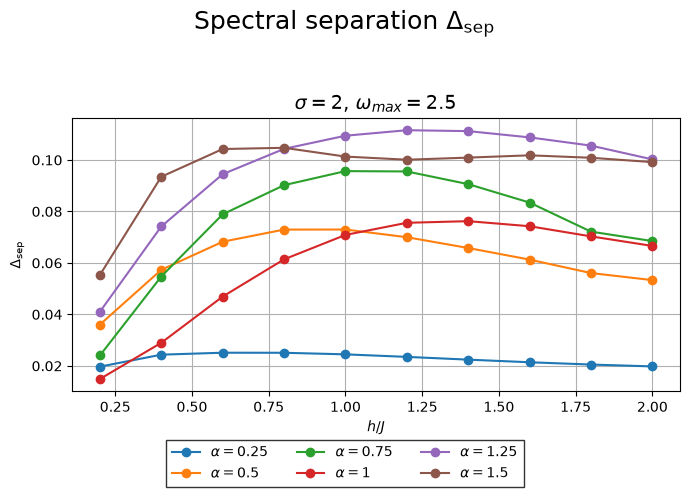

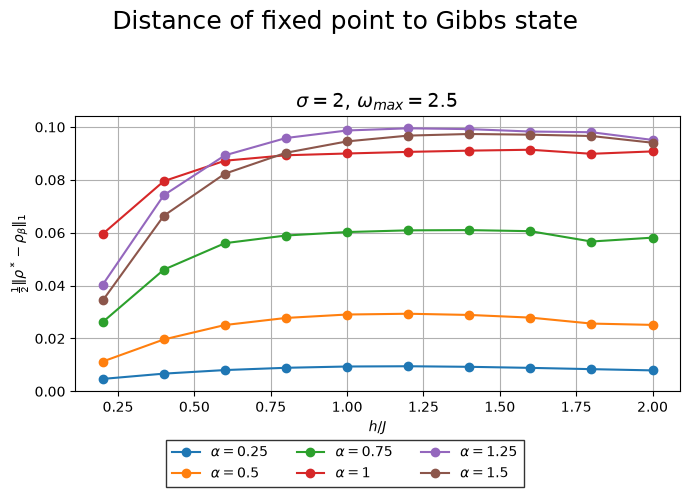

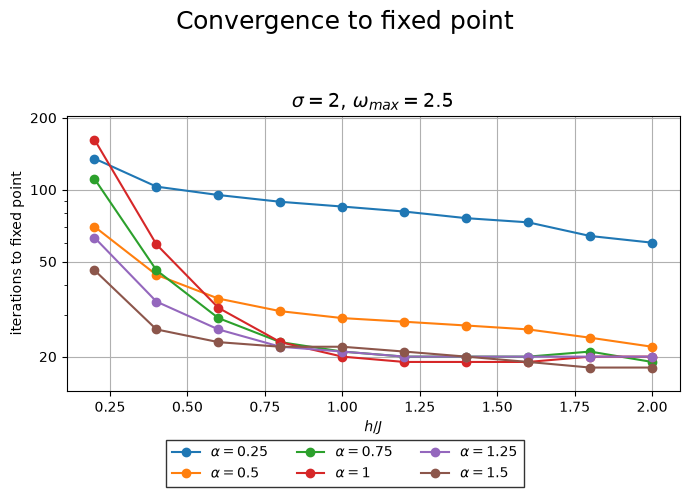

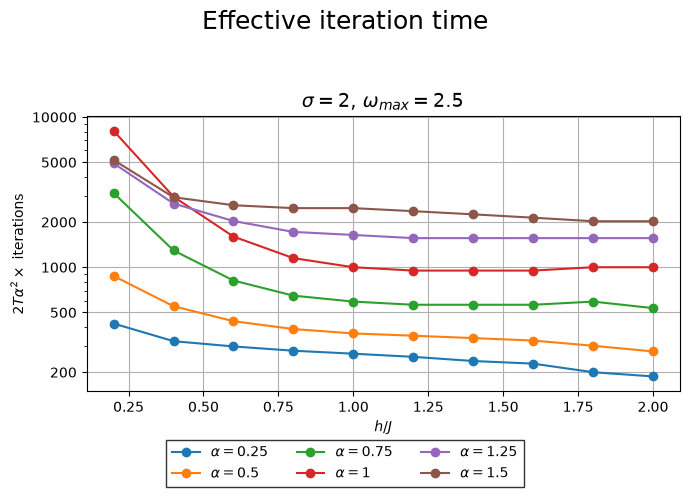

In [23]:
sigma_for_alpha_plot = 2.0
omega_values_to_plot = [2.5]
n_omega_panels = len(omega_values_to_plot)
if n_omega_panels == 0:
    raise ValueError('Select at least one omega_max value to plot.')

plt.style.use("default")

alpha_plot_data = grid_data[
    grid_data['alpha'].isin(selected_alphas)
    & np.isclose(grid_data['sigma'], sigma_for_alpha_plot)
].copy()
missing_omegas = np.setdiff1d(omega_values_to_plot, alpha_plot_data['omega_max'].unique())
if alpha_plot_data.empty or len(missing_omegas):
    raise ValueError(f'No data for alpha plot omega_max values: {missing_omegas.tolist()}')

# Nelder-Mead results are plotted at each optimized point's own h/J coordinate.
alpha_limit_data = alpha_plot_data
if nm_grid_data is not None:
    alpha_limit_data = pd.concat([
        alpha_limit_data,
        nm_grid_data[['h_over_J', 'num_iterations', 'effective_iteration_time']],
    ], ignore_index=True)

alpha_plot_titles = {
    'Delta_sep': r'Spectral separation $\Delta_{\mathrm{sep}}$',
    'trace_distance': r'Distance of fixed point to Gibbs state',
    'num_iterations': r'Convergence to fixed point',
    'effective_iteration_time': r'Effective iteration time',
}
plot_specs = [
    ('Delta_sep', r'$\Delta_{\mathrm{sep}}$'),
    ('trace_distance', r'$\frac{1}{2}\|\rho^* - \rho_\beta\|_1$'),
    ('num_iterations', 'iterations to fixed point'),
    ('effective_iteration_time', r'$2 T \alpha^2 \times$ iterations'),
]

iteration_values = alpha_limit_data['num_iterations'].to_numpy()
positive_iterations = iteration_values[np.isfinite(iteration_values) & (iteration_values > 0)]
if len(positive_iterations) == 0:
    print('Skipping iteration plots: no positive finite iteration counts are available.')
    plot_specs = plot_specs[:2]
else:
    log_lower = np.log10(positive_iterations.min()) - 0.1
    log_upper = np.log10(positive_iterations.max()) + 0.1
    iteration_ylim = (10**log_lower, 10**log_upper)
    iteration_ticks = [
        mantissa * 10**exponent
        for exponent in range(int(np.floor(log_lower)) - 1, int(np.ceil(log_upper)) + 2)
        for mantissa in (1, 2, 5)
        if iteration_ylim[0] <= mantissa * 10**exponent <= iteration_ylim[1]
    ]

    effective_values = alpha_limit_data['effective_iteration_time'].to_numpy()
    positive_effective = effective_values[np.isfinite(effective_values) & (effective_values > 0)]
    effective_log_lower = np.log10(positive_effective.min()) - 0.1
    effective_log_upper = np.log10(positive_effective.max()) + 0.1
    effective_ylim = (10**effective_log_lower, 10**effective_log_upper)
    effective_ticks = [
        mantissa * 10**exponent
        for exponent in range(int(np.floor(effective_log_lower)) - 1, int(np.ceil(effective_log_upper)) + 2)
        for mantissa in (1, 2, 5)
        if effective_ylim[0] <= mantissa * 10**exponent <= effective_ylim[1]
    ]

for column, ylabel in plot_specs:
    fig, axes = plt.subplots(1, n_omega_panels, figsize=(7 * n_omega_panels, 5.5), sharey=True)
    axes = np.atleast_1d(axes)
    fig.suptitle(alpha_plot_titles[column], fontsize=18)
    for ax, omega_max in zip(axes, omega_values_to_plot):
        plot_slice = alpha_plot_data[np.isclose(alpha_plot_data['omega_max'], omega_max)]
        for alpha in selected_alphas:
            line_data = plot_slice[np.isclose(plot_slice['alpha'], alpha)].sort_values('h_over_J')
            ax.plot(line_data['h_over_J'], line_data[column], marker='o', label=rf'$\alpha = {alpha:g}$')
        if nm_grid_data is not None and column == 'Delta_sep':
            line_data = nm_grid_data.sort_values('h_over_J')
            ax.plot(line_data['h_over_J'], line_data['Delta_sep'], 'k--D', label='NM optimum')
        elif nm_grid_data is not None and column in ('num_iterations', 'effective_iteration_time'):
            line_data = nm_grid_data.sort_values('h_over_J')
            ax.plot(line_data['h_over_J'], line_data[column], 'k--D', label='NM optimum')
        ax.set_xlabel(r'$h/J$')
        ax.set_ylabel(ylabel)
        if column == 'num_iterations':
            ax.set_yscale('log')
            ax.set_ylim(*iteration_ylim)
            ax.set_yticks(iteration_ticks)
            ax.set_yticklabels([f'{tick:g}' for tick in iteration_ticks])
            ax.yaxis.set_minor_formatter(NullFormatter())
        elif column == 'effective_iteration_time':
            ax.set_yscale('log')
            ax.set_ylim(*effective_ylim)
            ax.set_yticks(effective_ticks)
            ax.set_yticklabels([f'{tick:g}' for tick in effective_ticks])
            ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_title(rf'$\sigma = {sigma_for_alpha_plot:g}$, $\omega_{{max}} = {omega_max:g}$', fontsize=14)
        ax.grid(True)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.1), ncol=min(3, len(labels)), frameon=True, fancybox=False, edgecolor='black')
    fig.tight_layout(rect=[0, 0.18, 1, 0.93])
    fig.savefig(PLOT_DIR / f'grid_alpha_{column}_grid_{grid_nr}.png', dpi=300, bbox_inches='tight')
    plt.show()

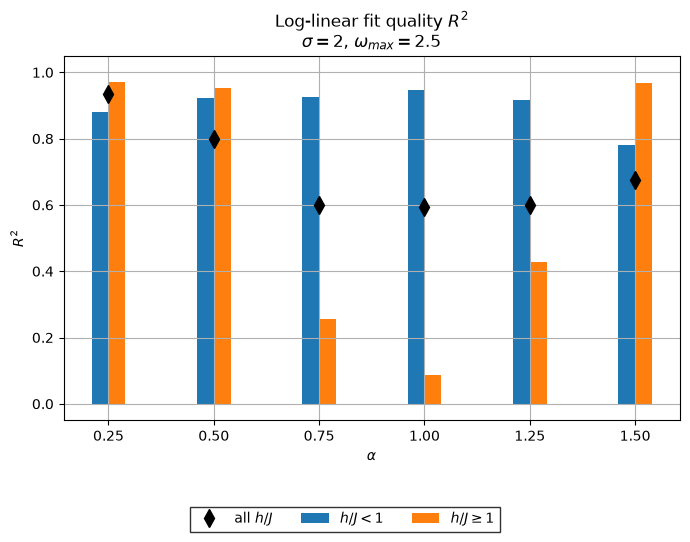

In [24]:
# Log-linear fits in two h/J ranges: log(iterations) = slope * h + intercept
r2_rows = []
h_ranges = {
    r'all $h/J$': lambda h_values: np.ones_like(h_values, dtype=bool),
    r'$h/J < 1$': lambda h_values: h_values < 1,
    r'$h/J \geq 1$': lambda h_values: h_values >= 1,
}
for omega_max in omega_values_to_plot:
    omega_data = alpha_plot_data[np.isclose(alpha_plot_data['omega_max'], omega_max)]
    for alpha in selected_alphas:
        line_data = omega_data[np.isclose(omega_data['alpha'], alpha)].sort_values('h')
        x = line_data['h'].to_numpy()
        iterations = line_data['num_iterations'].to_numpy()
        fit_mask = np.isfinite(x) & np.isfinite(iterations) & (iterations > 0)
        for h_range, range_mask in h_ranges.items():
            range_fit_mask = fit_mask & range_mask(x)
            if np.count_nonzero(range_fit_mask) < 2:
                slope, intercept, r_squared = np.nan, np.nan, np.nan
            else:
                slope, intercept = np.polyfit(x[range_fit_mask], np.log(iterations[range_fit_mask]), deg=1)
                fitted_log_iterations = slope * x[range_fit_mask] + intercept
                residual_sum_squares = np.sum((np.log(iterations[range_fit_mask]) - fitted_log_iterations) ** 2)
                total_sum_squares = np.sum((np.log(iterations[range_fit_mask]) - np.mean(np.log(iterations[range_fit_mask]))) ** 2)
                r_squared = np.nan if np.isclose(total_sum_squares, 0) else 1 - residual_sum_squares / total_sum_squares
            r2_rows.append({'alpha': alpha, 'omega_max': omega_max, 'h_range': h_range, 'slope': slope, 'intercept': intercept, 'r_squared': r_squared})

alpha_iteration_fit = pd.DataFrame(r2_rows)
# display(alpha_iteration_fit)

# This may be a raw LaTex string, e.g. r'Log-linear fit quality $R^2$'.
r2_plot_title = r'Log-linear fit quality $R^2$'
n_omega_panels = len(omega_values_to_plot)
fig, axes = plt.subplots(1, n_omega_panels, figsize=(7 * n_omega_panels, 5.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, omega_max in zip(axes, omega_values_to_plot):
    r2_data = alpha_iteration_fit[np.isclose(alpha_iteration_fit['omega_max'], omega_max)]
    bar_width = 0.04
    for h_range, offset in [(r'$h/J < 1$', -bar_width / 2), (r'$h/J \geq 1$', bar_width / 2)]:
        range_data = r2_data[r2_data['h_range'] == h_range].sort_values('alpha')
        ax.bar(range_data['alpha'] + offset, range_data['r_squared'], width=bar_width, label=h_range)
    whole_interval_data = r2_data[r2_data['h_range'] == r'all $h/J$'].sort_values('alpha')
    ax.plot(whole_interval_data['alpha'], whole_interval_data['r_squared'], 'kd', markersize=9, label=r'all $h/J$', zorder=3)
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'$R^2$')
    ax.set_xticks(selected_alphas)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{r2_plot_title}\n' + rf'$\sigma = {sigma_for_alpha_plot:g}$, $\omega_{{max}} = {omega_max:g}$')
    ax.grid(True)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=len(labels), frameon=True, fancybox=False, edgecolor='black')
fig.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig(PLOT_DIR / f'grid_alpha_iteration_fit_r2_grid_{grid_nr}.png', dpi=300, bbox_inches='tight')
plt.show()

## Plots by sigma

Each line is one selected sigma value, at the chosen fixed alpha and `omega_max`.

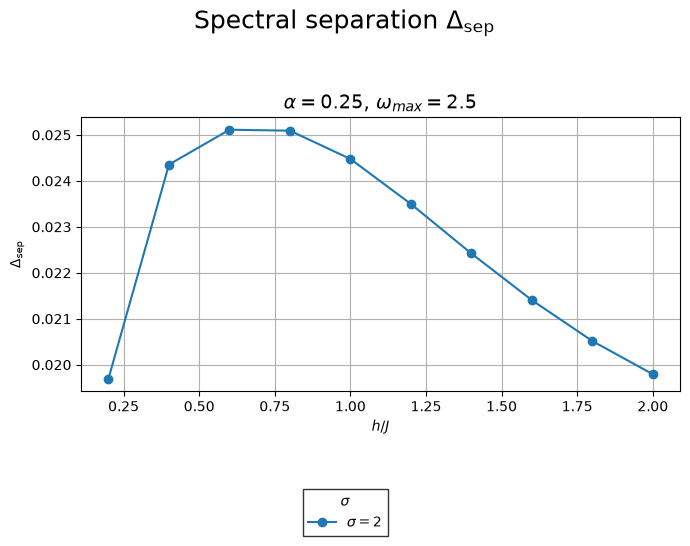

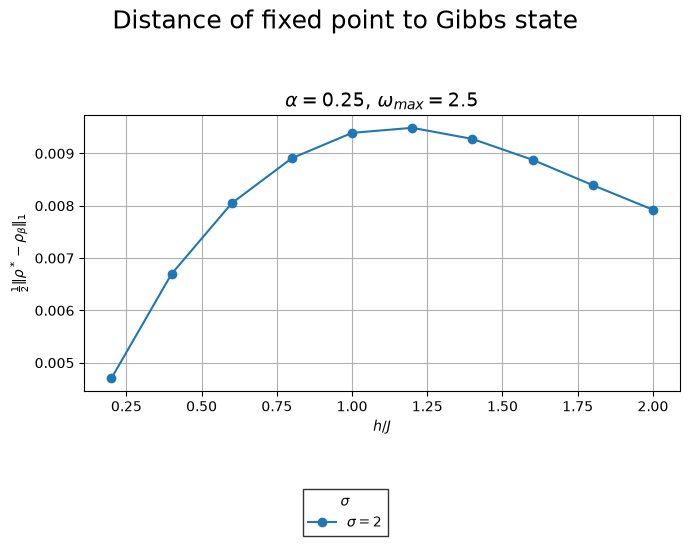

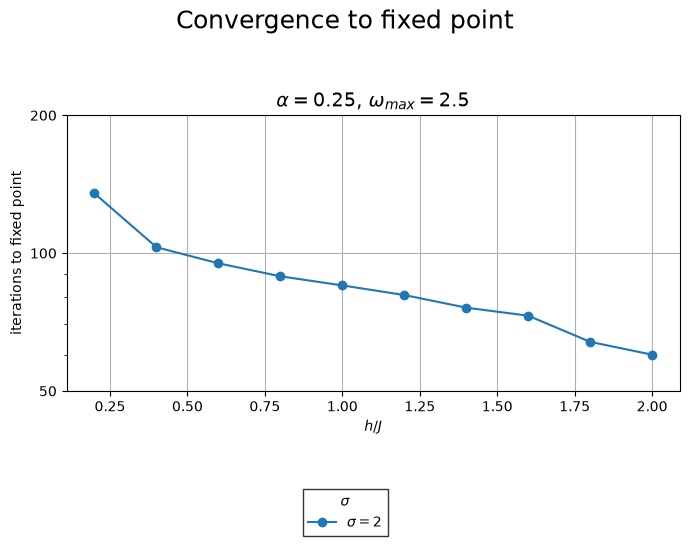

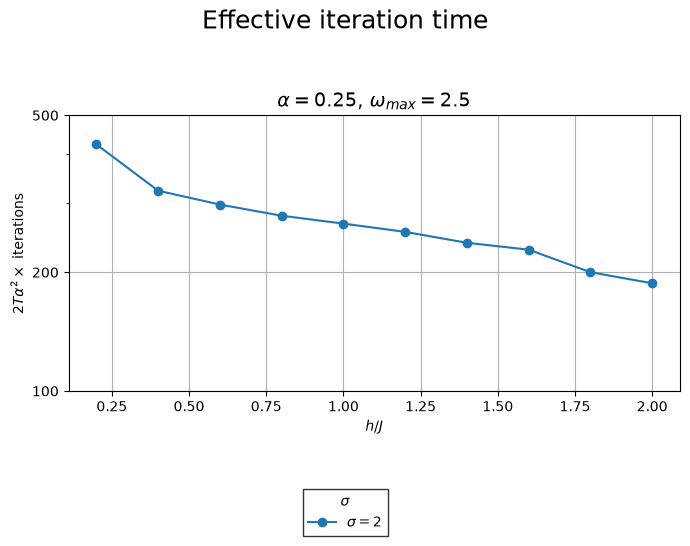

In [26]:
from matplotlib.ticker import NullFormatter

alpha_for_sigma_plot = 0.25
omega_values_to_plot = [2.5]

n_omega_panels = len(omega_values_to_plot)
if n_omega_panels == 0:
    raise ValueError('Select at least one omega_max value to plot.')

sigma_plot_data = grid_data[
    grid_data['sigma'].isin(selected_sigmas)
    & np.isclose(grid_data['alpha'], alpha_for_sigma_plot)
].copy()
missing_omegas = np.setdiff1d(omega_values_to_plot, sigma_plot_data['omega_max'].unique())
if sigma_plot_data.empty or len(missing_omegas):
    raise ValueError(f'No data for sigma plot omega_max values: {missing_omegas.tolist()}')

# Use raw strings (r'...') for titles containing LaTex, e.g. r'Spectral separation $\Delta_{\mathrm{sep}}$'.
sigma_plot_titles = {
    'Delta_sep': r'Spectral separation $\Delta_{\mathrm{sep}}$',
    'trace_distance': r'Distance of fixed point to Gibbs state',
    'num_iterations': r'Convergence to fixed point',
    'effective_iteration_time': r'Effective iteration time',
}

for column, ylabel in zip(
    ['Delta_sep', 'trace_distance', 'num_iterations', 'effective_iteration_time'],
    [r'$\Delta_{\mathrm{sep}}$', r'$\frac{1}{2}\|\rho^* - \rho_\beta\|_1$', 'iterations to fixed point', r'$2 T \alpha^2 \times$ iterations'],
):
    if column in ('num_iterations', 'effective_iteration_time'):
        values = sigma_plot_data[column].to_numpy()
        if not np.any(np.isfinite(values) & (values > 0)):
            print(f'Skipping {column}: no positive finite values are available for the selected sigma plot.')
            continue
    fig, axes = plt.subplots(1, n_omega_panels, figsize=(7 * n_omega_panels, 5.5), sharey=column not in ('num_iterations', 'effective_iteration_time'))
    axes = np.atleast_1d(axes)
    fig.suptitle(sigma_plot_titles[column], fontsize=18)
    for ax, omega_max in zip(axes, omega_values_to_plot):
        plot_slice = sigma_plot_data[np.isclose(sigma_plot_data['omega_max'], omega_max)]
        for sigma in selected_sigmas:
            line_data = plot_slice[np.isclose(plot_slice['sigma'], sigma)].sort_values('h')
            ax.plot(line_data['h'], line_data[column], marker='o', label=rf'$\sigma = {sigma:g}$')
        ax.set_xlabel(r'$h/J$')
        ax.set_ylabel(ylabel)
        if column in ('num_iterations', 'effective_iteration_time'):
            values = plot_slice[column].to_numpy()
            positive_values = values[np.isfinite(values) & (values > 0)]
            tick_candidates = [
                mantissa * 10**exponent
                for exponent in range(int(np.floor(np.log10(positive_values.min()))) - 1, int(np.ceil(np.log10(positive_values.max()))) + 2)
                for mantissa in (1, 2, 5)
            ]
            lower_tick = max(tick for tick in tick_candidates if tick <= positive_values.min())
            upper_tick = min(tick for tick in tick_candidates if tick >= positive_values.max())
            iteration_ylim = (lower_tick, upper_tick)
            iteration_ticks = [tick for tick in tick_candidates if lower_tick <= tick <= upper_tick]
            ax.set_yscale('log')
            ax.set_ylim(*iteration_ylim)
            ax.set_yticks(iteration_ticks)
            ax.set_yticklabels([f'{tick:g}' for tick in iteration_ticks])
            ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_title(rf'$\alpha = {alpha_for_sigma_plot:g}$, $\omega_{{max}} = {omega_max:g}$', fontsize=14)
        ax.grid(True)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=r'$\sigma$', loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=min(3, len(labels)), frameon=True, fancybox=False, edgecolor='black')
    fig.tight_layout(rect=[0, 0.18, 1, 0.93])
    fig.savefig(PLOT_DIR / f'grid_sigma_{column}_grid_{grid_nr}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Non-normality residual, resolved separately by alpha and by sigma.
normality_omega_values = [
    omega for omega in omega_values_to_plot
    if np.any(np.isclose(grid_data['omega_max'], omega))
]
if not normality_omega_values:
    raise ValueError('None of the selected omega_max values are available for the non-normality plots.')

fig, axes = plt.subplots(1, len(normality_omega_values), figsize=(7 * len(normality_omega_values), 5.5), squeeze=False)
axes = axes.ravel()
for ax, omega_max in zip(axes, normality_omega_values):
    plot_slice = alpha_plot_data[np.isclose(alpha_plot_data['omega_max'], omega_max)]
    for alpha in selected_alphas:
        line_data = plot_slice[np.isclose(plot_slice['alpha'], alpha)].sort_values('h_over_J')
        ax.plot(line_data['h_over_J'], line_data['normality_residual'], marker='o', label=rf'$\alpha = {alpha:g}$')
    if nm_grid_data is not None and 'normality_residual' in nm_grid_data:
        nm_line_data = nm_grid_data[np.isfinite(nm_grid_data['normality_residual'])].sort_values('h_over_J')
        if not nm_line_data.empty:
            ax.plot(nm_line_data['h_over_J'], nm_line_data['normality_residual'], 'k--D', label='NM optimum (all parameters vary)')
    ax.set_xlabel(r'$h/J$')
    ax.set_ylabel('Non-normality residual')
    ax.set_title(rf'$\sigma = {sigma_for_alpha_plot:g}$, $\omega_{{max}} = {omega_max:g}$')
    ax.grid(True)
    ax.legend(frameon=True, fancybox=False, edgecolor='black')
fig.suptitle('Non-normality residual by alpha', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(PLOT_DIR / f'grid_alpha_normality_residual_grid_{grid_nr}.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, len(normality_omega_values), figsize=(7 * len(normality_omega_values), 5.5), squeeze=False)
axes = axes.ravel()
for ax, omega_max in zip(axes, normality_omega_values):
    plot_slice = sigma_plot_data[np.isclose(sigma_plot_data['omega_max'], omega_max)]
    for sigma in selected_sigmas:
        line_data = plot_slice[np.isclose(plot_slice['sigma'], sigma)].sort_values('h_over_J')
        ax.plot(line_data['h_over_J'], line_data['normality_residual'], marker='o', label=rf'$\sigma = {sigma:g}$')
    ax.set_xlabel(r'$h/J$')
    ax.set_ylabel('Non-normality residual')
    ax.set_title(rf'$\alpha = {alpha_for_sigma_plot:g}$, $\omega_{{max}} = {omega_max:g}$')
    ax.grid(True)
    ax.legend(frameon=True, fancybox=False, edgecolor='black')
fig.suptitle('Non-normality residual by sigma', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(PLOT_DIR / f'grid_sigma_normality_residual_grid_{grid_nr}.png', dpi=300, bbox_inches='tight')
plt.show()


## Beta-sweep plots

Compare the five historical beta sweeps at $h=1.2$ and $\sigma=2$. The global spectral gap is intentionally excluded because these archives contain only partial spectra.

In [47]:
# (npz-number, alpha)
beta_sweeps = [
    (21, 0.25),
    (24, 0.35),
    (20, 0.50),
    (22, 0.75),
    (23, 1.00),
]

beta_frames = []
for nbr, alpha in beta_sweeps:
    beta_path = Path(f'data/superoperator_N4_beta_sweep_{nbr}.npz')
    with np.load(beta_path) as beta_archive:
        beta_frames.append(pd.DataFrame({
            'beta': beta_archive['beta'],
            'alpha': alpha,
            'Delta_sep': beta_archive['Delta_sep'],
            'trace_distance': beta_archive['trace_distance'],
            'num_iterations': beta_archive['num_iterations'],
        }))

beta_data = pd.concat(beta_frames, ignore_index=True)
print(f'Loaded {len(beta_data)} beta-sweep points from {len(beta_sweeps)} files.')
print('Reconstructed beta-sweep parameters:', beta_plot_parameters)

Loaded 100 beta-sweep points from 5 files.


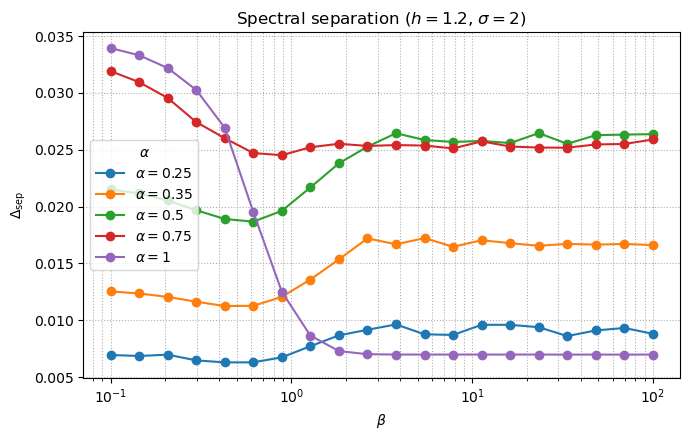

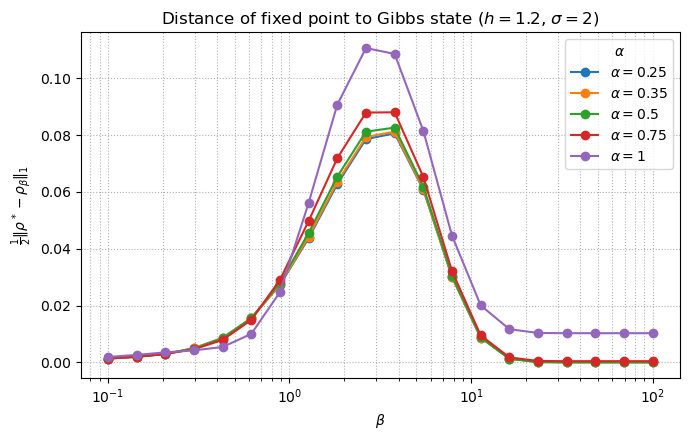

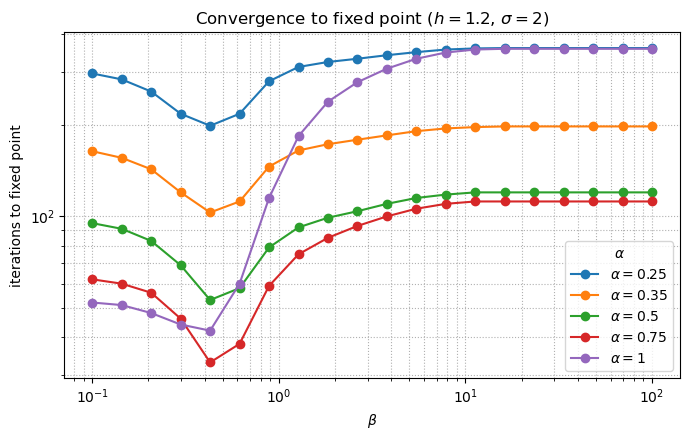

In [48]:
beta_plot_specs = [
    ('Delta_sep', r'$\Delta_{\mathrm{sep}}$', 'Spectral separation', 'separation_beta.png', False),
    ('trace_distance', r'$\frac{1}{2}\|\rho^* - \rho_\beta\|_1$', 'Distance of fixed point to Gibbs state', 'distance_to_gibbs_beta.png', False),
    ('num_iterations', 'iterations to fixed point', 'Convergence to fixed point', 'iterations_beta.png', True),
]

for column, ylabel, title, filename, log_y in beta_plot_specs:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for alpha, line_data in beta_data.groupby('alpha', sort=True):
        line_data = line_data.sort_values('beta')
        ax.plot(line_data['beta'], line_data[column], marker='o', label=rf'$\alpha = {alpha:g}$')
    ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(ylabel)
    ax.set_title(
        title + '\n' + rf"$h/J = {beta_plot_parameters['h'] / beta_plot_parameters['J']:g}$, $\sigma = {beta_plot_parameters['sigma']:g}$, $\omega_{{\max}} = {beta_plot_parameters['omega_max']:g}$"
    )
    ax.legend(title=r'$\alpha$')
    ax.grid(True, which='both', linestyle=':')
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

## Nelder-Mead optimal parameter analysis

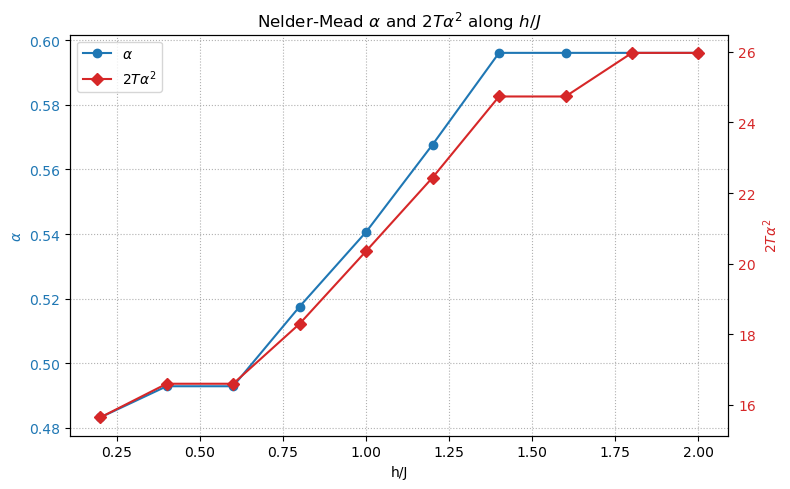

In [109]:
if nm_grid_data is None:
    raise ValueError('Load a Nelder-Mead h-sweep archive to plot optimized parameters.')

nm_parameter_data = nm_grid_data.sort_values('h_over_J').copy()

# Optimized coupling and its coupling-weighted effective interaction time.
nm_parameter_data['effective_interaction_time'] = (
    2 * nm_parameter_data['T'] * nm_parameter_data['alpha']**2
)
fig, alpha_time_axis = plt.subplots(figsize=(8, 5))
effective_time_axis = alpha_time_axis.twinx()

alpha_time_line = alpha_time_axis.plot(
    nm_parameter_data['h_over_J'], nm_parameter_data['alpha'],
    color='tab:blue', marker='o', label=r'$\alpha$'
)[0]
effective_time_line = effective_time_axis.plot(
    nm_parameter_data['h_over_J'], nm_parameter_data['effective_interaction_time'],
    color='tab:red', marker='D', label=r'$2T\alpha^2$'
)[0]

alpha_time_axis.set_xlabel('h/J')
alpha_time_axis.set_ylabel(r'$\alpha$', color='tab:blue')
effective_time_axis.set_ylabel(r'$2T\alpha^2$', color='tab:red')
alpha_time_axis.tick_params(axis='y', labelcolor='tab:blue')
effective_time_axis.tick_params(axis='y', labelcolor='tab:red')
alpha_time_axis.set_title(r'Nelder-Mead $\alpha$ and $2T\alpha^2$ along $h/J$')
alpha_time_axis.grid(True, linestyle=':')
alpha_time_axis.legend(
    [alpha_time_line, effective_time_line],
    [line.get_label() for line in (alpha_time_line, effective_time_line)],
    loc='best',
)
fig.tight_layout()
fig.savefig(PLOT_DIR / f'nelder_mead_h_alpha_effective_time_run_{nm_run_nr}.png', dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
if nm_grid_data is None:
    raise ValueError('Load a Nelder-Mead h-sweep archive to plot optimized parameters.')

nm_omega_sigma_data = nm_grid_data.sort_values('h_over_J')
fig, omega_axis = plt.subplots(figsize=(8, 5))
sigma_axis = omega_axis.twinx()

omega_line = omega_axis.plot(
    nm_omega_sigma_data['h_over_J'], nm_omega_sigma_data['omega_max'],
    color='tab:blue', marker='o', label=r'$\omega_{\max}$'
)[0]
sigma_line = sigma_axis.plot(
    nm_omega_sigma_data['h_over_J'], nm_omega_sigma_data['sigma'],
    color='tab:red', marker='D', label=r'$\sigma$'
)[0]

omega_axis.set_xlabel(r'$h/J$')
omega_axis.set_ylabel(r'$\omega_{\max}$', color='tab:blue')
sigma_axis.set_ylabel(r'$\sigma$', color='tab:red')
omega_axis.tick_params(axis='y', labelcolor='tab:blue')
sigma_axis.tick_params(axis='y', labelcolor='tab:red')
omega_axis.set_title(r'Nelder-Mead $\omega_{\max}$ and $\sigma$ along $h/J$')
omega_axis.grid(True, linestyle=':')
omega_axis.legend(
    [omega_line, sigma_line],
    [line.get_label() for line in (omega_line, sigma_line)],
    loc='best',
)
fig.tight_layout()
fig.savefig(PLOT_DIR / f'nelder_mead_h_omega_max_sigma_run_{nm_run_nr}.png', dpi=300, bbox_inches='tight')
plt.show()
